# Adaptive-Rewiring Simulation Notebook

This notebook contains the core simulation, measurement, and plotting workflow used in the paper.

Required packages: `numpy`, `pandas`, `matplotlib`, `networkx`, `scipy`, and `python-louvain` (`pip install python-louvain`).


In [1]:
import numpy as np
import networkx as nx
import random
import pandas as pd
from collections import defaultdict, Counter
import community as community_louvain  # pip install python-louvain
import os
import matplotlib.pyplot as plt
from math import ceil
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.signal import welch, detrend, get_window
import random
from scipy.stats import linregress
from scipy.ndimage import gaussian_filter1d
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable



# 设置全局字体大小
plt.rcParams['font.size'] = 12 
rng = np.random.default_rng(42)


/Users/ducongcong/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [23]:
# -----------------------------
# Parameters
# -----------------------------
V = 200
d = 10
E = V*d/2

# for logistic model
a = 3.57
ep = 0# weight for coupled term
# for avalanche
max_avalanches = 5000  # 产生多少个雪崩（每个雪崩一次重连）
record_every = 100     # 每多少个雪崩记录一次网络指标

rewire_every = 5
p_base = 0.1   #雪崩传播概率 0.095, 0.1，0.145
noise_level=0

mode = 'ar' #ar no random random-dp
network = 'random' # random, sw, regular, modular

## Helper Functions


In [24]:
def one_avalanche(G, p_base, rng, track_edges=True):
    seed_node = rng.integers(0, G.number_of_nodes())
    active = {seed_node}
    size = 0
    duration = 0
    series = []

    # 本次雪崩使用过的边（无向边 canonical: (min,max)）
    used_edges = set() if track_edges else None
    # 如果你还想统计成功传播事件次数：
    used_edges_events = {} if track_edges else None  # dict edge->count

    while active:
        series.append(len(active))
        size += len(active)
        duration += 1

        next_active = set()
        for u in active:
            xu = G.nodes[u]["activation"]
            for v in G.neighbors(u):
                xv = G.nodes[v]["activation"]
                p = p_base * (1 - abs(xu - xv))
                if rng.random() < p:
                    next_active.add(v)

                    if track_edges:
                        e = (u, v) if u < v else (v, u)
                        used_edges.add(e)
                        used_edges_events[e] = used_edges_events.get(e, 0) + 1

        active = next_active

    if track_edges:
        return size, duration, series, used_edges, used_edges_events
    else:
        return size, duration, series

In [25]:
def generate_modular_network(V, d, n_modules, p_in=0.15, p_out=0.01, seed=None):
    
    rng = np.random.default_rng(seed)
    
    # --- 1. Assign nodes to modules ---
    sizes = [V // n_modules] * n_modules
    for i in range(V % n_modules):
        sizes[i] += 1
    modules = {}
    node_index = 0
    for m, size in enumerate(sizes):
        for _ in range(size):
            modules[node_index] = m
            node_index += 1
    
    # --- 2. Create empty graph ---
    G = nx.Graph()
    G.add_nodes_from(range(V))
    
    # --- 3. Add edges ---
    # Compute probabilities dynamically based on d if desired
    if p_in is None or p_out is None:
        # approximate: E = V*d/2, split by ratio r=p_in/p_out
        p_out = d / (V * (1 + (n_modules - 1)))
        p_in = p_out * n_modules  # make intra-module higher
    
    for i in range(V):
        for j in range(i+1, V):
            same_module = (modules[i] == modules[j])
            p = p_in if same_module else p_out
            if rng.random() < p:
                G.add_edge(i, j)
    
    # --- 4. Compute modularity using Louvain ---
    partition = community_louvain.best_partition(G)
    Q = community_louvain.modularity(partition, G)
    
    # # --- 5. Optional plot ---
    # pos = nx.spring_layout(G)
    # cmap = plt.cm.get_cmap('tab10', n_modules)
    # colors = [cmap(modules[i]) for i in G.nodes()]
    # plt.figure(figsize=(6,6))
    # nx.draw_networkx(G, pos=pos, node_color=colors, with_labels=False, node_size=50)
    # plt.title(f"Modular network (V={V}, Q={Q:.3f})")
    # plt.axis('off')
    # plt.show()
    
    return G, Q, modules

In [26]:
def show_network(G, title, cmap):
    # 获取节点值
    node_values = [G.nodes[node]['activation'] for node in G.nodes]

    # 创建一个 colormap
    # cmap = cm.Spectral  # 选择一个颜色映射，例如 'viridis'
    norm = mcolors.Normalize(vmin=0, vmax=1)
    # norm = mcolors.Normalize(vmin=min(node_values), vmax=max(node_values))

    # 根据节点值生成颜色
    node_colors = [cmap(norm(value)) for value in node_values]

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array(node_values)

    pos = nx.spring_layout(G,seed=1)
    options = {
        "node_color": node_colors,
        "node_size": 100,
        "edge_color": "grey",
        "linewidths": 0,
        "width": 0.5,
    }
    nx.draw(G, pos, **options)
    # nx.draw_networkx(G, with_labels=True, node_color=node_colors, cmap=cmap, node_size=500)
    # nx.draw_circular(G, with_labels=True, node_color=node_colors, cmap=cmap, node_size=500)
    plt.title(f'{title}')
    plt.colorbar(sm, label="activation")
    plt.show() 

def plot_community(G, T, Flag):
    # ---- 1) 社区检测（Louvain） ----
    # 有向图建议先做无向化用于检测：UG = G.to_undirected()
    UG = G.to_undirected()

    part = community_louvain.best_partition(UG, weight='weight')  # dict: node -> community id
    Q = community_louvain.modularity(part, UG, weight='weight')   # 模块度

    # ---- 2) 按社区重排节点（社区内可按度或任意规则再排）----
    # 先按社区号，再按节点度降序
    nodes = list(UG.nodes())
    comm_ids = sorted(set(part.values()), key=lambda c: -sum(1 for v in part if part[v]==c))  # 社区按大小排序
    ordered_nodes = []
    boundaries = []  # 用来画分块边界的位置（矩阵索引）
    for c in comm_ids:
        members = [v for v in nodes if part[v] == c]
        members.sort(key=lambda v: UG.degree(v), reverse=True)
        start = len(ordered_nodes)
        ordered_nodes.extend(members)
        end = len(ordered_nodes)
        boundaries.append(end)  # 社区块的结束索引（画格线用）

    # 建立节点->新索引的映射
    idx = {n:i for i,n in enumerate(ordered_nodes)}

    # ---- 3) 构造按新顺序排列的邻接矩阵 ----
    # 若是有向加权图：
    A = nx.to_numpy_array(G, nodelist=ordered_nodes, weight='weight', dtype=float)
    # 无权可用 dtype=int / weight=None

    # ---- 4) 画热图 + 社区边界 ----
    plt.figure(figsize=(3,3))
    im = plt.imshow(A, cmap='BuPu', interpolation='nearest')
    plt.title(f'T={T} | Adjacency Matrix')
    if Flag == True:
        plt.title(f'T={T} | Adjacency Matrix| Q={Q:.3f}')

    # plt.xlabel('Node (reordered)')
    # plt.ylabel('Node (reordered)')
    # plt.colorbar(im, fraction=0.046, pad=0.04, label='Weight')

    # 画出社区分块边界
    for b in boundaries[:-1]:   # 最后一个等于N，不画
        plt.axhline(b-0.5, color='w', lw=1)
        plt.axvline(b-0.5, color='w', lw=1)

    plt.tight_layout()
    plt.show()

In [27]:
def generate_network(network,V,d,n_modules,p,seed=rng, show=False):
    if network == 'random':
        G = nx.gnm_random_graph(V, E,seed)
    elif network == 'regular':
        G = nx.random_regular_graph(d, V)
    elif network == 'sw':
        G = nx.watts_strogatz_graph(V, d, p)
    elif network =='modular':
        G, Q, modules = generate_modular_network(V, d, n_modules,p_in=0.15, p_out=0.01, seed=rng)
    else:
        raise ValueError("Unknown network: 'random' | 'regular' | 'sw'| 'modular'")
    
    for n in G.nodes():
        G.nodes[n]["activation"] = rng.uniform(0, 1.0)
    if show == True:
        show_network(G, 'Initial Network', cm.plasma)
    return G

In [28]:
def update_activation(G,ep,noise_level):
    for n in G.nodes():
        # uncoupled logistic map
        G.nodes[n]["activation"]=a*G.nodes[n]["activation"]*(1-G.nodes[n]["activation"])


def rewiring_no(G):
    return

def rewiring_random_degree_preserving(G, trials=1):
    """随机双边交换，严格保持度数。不允许自环/多重边。"""
    edges = list(G.edges())
    if len(edges) < 2:
        return
    for _ in range(trials):
        (a, c) = random.choice(edges)
        (b, d) = random.choice(edges)
        # 避免重复/自环
        if len({a, b, c, d}) < 4:
            continue
        # 计划替换为 (a,d) 与 (b,c)
        if G.has_edge(a, d) or G.has_edge(b, c):
            continue
        # 执行交换
        G.remove_edge(a, c)
        G.remove_edge(b, d)
        G.add_edge(a, d)
        G.add_edge(b, c)
        # 刷新本地 edge 列表（可省略，保守起见）
        edges = list(G.edges())

def rewiring_random(G):
    a = random.choice(list(G.nodes()))
    candidates = [u for u in G.nodes() if u != a]
    if not candidates:
        return
    b = random.choice(candidates)
    if not G.has_edge(a, b):
        G.add_edge(a, b)
        nbrs = list(G.neighbors(a))
        if len(nbrs) > 1:
            c_cands = [u for u in nbrs if u != b] or [b]
            c = random.choice(c_cands)
            if c != b and G.has_edge(a, c):
                G.remove_edge(a, c)

def rewiring_ar(G):
    cnt=0
    a = random.choice(list(G.nodes()))
    act_a = G.nodes[a]["activation"]
    b = min((u for u in G.nodes() if u != a),
            key=lambda u: abs(G.nodes[u]["activation"] - act_a))
    # print(f'step1: {a}')
    if not G.has_edge(a, b):
        # print(f'step2: {b}')
        G.add_edge(a, b)
        nbrs = list(G.neighbors(a))
        c = max(nbrs, key=lambda u: abs(G.nodes[u]["activation"] - act_a))
        G.remove_edge(a, c)
        cnt=1
        # if len(nbrs) > 1:
        #     c = max(nbrs, key=lambda u: abs(G.nodes[u]["activation"] - act_a))
        #     if c != b and G.has_edge(a, c):
        #         G.remove_edge(a, c)
    return cnt

In [29]:
# -----------------------------
# Network measures
# -----------------------------
def spectral_radius(G):
    A = nx.to_numpy_array(G, dtype=float)
    if A.size == 0:
        return np.nan
    vals = np.linalg.eigvals(A)
    return float(np.max(np.real(vals)))


def compute_network_measures(G):
    """Compute graph-level summary statistics on the current network."""
    m = {}
    comps = list(nx.connected_components(G))
    m["n_components"] = len(comps)
    gcc = G.subgraph(max(comps, key=len)).copy() if comps else G
    m["gcc_size"] = gcc.number_of_nodes()
    m["gcc_frac"] = m["gcc_size"] / G.number_of_nodes() if G.number_of_nodes() > 0 else np.nan

    # Basic path-length metrics are evaluated on the giant connected component.
    if gcc.number_of_nodes() >= 2 and nx.is_connected(gcc):
        m["avg_path_length"] = nx.average_shortest_path_length(gcc)
        m["diameter"] = nx.diameter(gcc)
    else:
        m["avg_path_length"] = np.nan
        m["diameter"] = np.nan

    m["efficiency"] = nx.global_efficiency(G)
    m["clustering"] = nx.average_clustering(G)
    m["assortativity"] = nx.degree_assortativity_coefficient(G)

    rc = nx.rich_club_coefficient(G, normalized=False)
    m["rich_club_coeff"] = float(np.mean(list(rc.values()))) if rc else np.nan

    bc = nx.betweenness_centrality(G)
    m["betweenness"] = float(np.mean(list(bc.values()))) if bc else np.nan

    if G.number_of_edges() > 0 and G.number_of_nodes() > 0:
        part = community_louvain.best_partition(G)
        m["modularity"] = community_louvain.modularity(part, G)
    else:
        part = {n: 0 for n in G.nodes()}
        m["modularity"] = np.nan

    E = G.number_of_edges()
    if E > 0:
        inter_edges = sum(1 for u, v in G.edges() if part[u] != part[v])
        intra_edges = E - inter_edges
        m["inter_edge_frac"] = inter_edges / E
        m["intra_edge_frac"] = intra_edges / E
    else:
        m["inter_edge_frac"] = np.nan
        m["intra_edge_frac"] = np.nan

    # Participation coefficient: how broadly each node connects across modules.
    deg = dict(G.degree())
    P_vals = []
    for i in G.nodes():
        k_i = deg[i]
        if k_i == 0:
            P_vals.append(np.nan)
            continue

        neigh_modules = Counter(part[j] for j in G.neighbors(i))
        sum_sq = 0.0
        for k_is in neigh_modules.values():
            frac = k_is / k_i
            sum_sq += frac ** 2
        P_vals.append(1.0 - sum_sq)

    P_arr = np.array(P_vals, dtype=float)
    if np.all(np.isnan(P_arr)):
        m["participation_mean"] = np.nan
        m["participation_std"] = np.nan
    else:
        m["participation_mean"] = float(np.nanmean(P_arr))
        m["participation_std"] = float(np.nanstd(P_arr))

    # Within-module degree z-score.
    module_nodes = defaultdict(list)
    for node, comm in part.items():
        module_nodes[comm].append(node)

    z_all = []
    for comm, nodes in module_nodes.items():
        k_in = []
        for n in nodes:
            kin = sum(1 for nbr in G.neighbors(n) if part[nbr] == comm)
            k_in.append(kin)

        k_in = np.array(k_in, dtype=float)
        if len(k_in) <= 1 or np.allclose(np.std(k_in), 0.0):
            z = np.zeros_like(k_in)
        else:
            z = (k_in - k_in.mean()) / k_in.std()
        z_all.extend(z.tolist())

    if z_all:
        z_arr = np.array(z_all, dtype=float)
        m["wmdeg_z_mean"] = float(np.mean(z_arr))
        m["wmdeg_z_std"] = float(np.std(z_arr))
    else:
        m["wmdeg_z_mean"] = np.nan
        m["wmdeg_z_std"] = np.nan

    if E > 0:
        ebc = nx.edge_betweenness_centrality(G)
        eb_vals = np.array(list(ebc.values()), dtype=float)
        m["edge_bw_mean"] = float(eb_vals.mean())
        m["edge_bw_max"] = float(eb_vals.max())
        m["edge_bw_std"] = float(eb_vals.std())
    else:
        m["edge_bw_mean"] = np.nan
        m["edge_bw_max"] = np.nan
        m["edge_bw_std"] = np.nan

    lam1 = spectral_radius(G)
    m["spectral_radius"] = lam1

    try:
        m["crit_gap_signed"] = p_base * lam1 - 1.0
        m["crit_gap_abs"] = abs(m["crit_gap_signed"])
    except NameError:
        m["crit_gap_signed"] = np.nan
        m["crit_gap_abs"] = np.nan

    if G.number_of_nodes() >= 2:
        L = nx.laplacian_matrix(G).astype(float).todense()
        evals = np.linalg.eigvalsh(L)
        m["algebraic_connectivity"] = float(evals[1]) if len(evals) >= 2 else 0.0
    else:
        m["algebraic_connectivity"] = np.nan

    return m


In [30]:
# -----------------------------
# LRTC helpers (DFA & PSD slope)
# -----------------------------
def dfa_alpha(x, min_window=4, max_frac=0.25, n_scales=12):
    """Simple DFA returning scaling exponent alpha."""
    x = np.asarray(x, dtype=float)
    if len(x) < 16:
        return np.nan
    x = x - np.mean(x)
    y = np.cumsum(x)
    N = len(y)
    s_min = min_window
    s_max = int(N * max_frac)
    if s_max <= s_min + 1:
        return np.nan
    scales = np.unique(np.logspace(np.log10(s_min), np.log10(s_max), n_scales).astype(int))
    Fs, Ss = [], []
    for s in scales:
        nseg = N // s
        if nseg < 2:
            continue
        rms = []
        t = np.arange(s)
        A = np.vstack([t, np.ones_like(t)]).T

        for k in range(nseg):
            seg = y[k*s:(k+1)*s]
            a, b = np.linalg.lstsq(A, seg, rcond=None)[0]
            trend = a*t + b
            rms.append(np.sqrt(np.mean((seg - trend)**2)))

        if len(rms) > 0:
            F_s = np.sqrt(np.mean(np.square(rms)))   # = sqrt(mean(rms^2))
            Fs.append(F_s)
            Ss.append(s) 
    if len(Fs) < 2:
        return np.nan
    coeff = np.polyfit(np.log10(Ss), np.log10(Fs), 1)
    return float(coeff[0])

def psd_loglog_slope_robust(x, fs=1.0, band=None, use_diff=False,
                            p_lo=15, p_hi=85, n_logbins=24):
    """
    Robust PSD log–log slope near 1/f.
    Parameters
    ----------
    x : array-like
        Continuous per-time-step activity (NOT cumulative).
    fs : float
        Sampling rate. If you simulated in steps, fs=1.0 is fine.
    band : tuple or None
        (f_lo, f_hi). If None, pick mid-band by log-frequency percentiles (p_lo,p_hi).
    use_diff : bool
        If True, fit slope on first-differenced series (helps nonstationary A(t)).
    p_lo, p_hi : float
        Percentiles (in log10 f) to define the mid-band when band=None.
    n_logbins : int
        Number of logarithmic bins for smoothing before regress.

    Returns
    -------
    slope : float
        Log-log slope (should be ~ -1 near 1/f).
    info : dict
        Diagnostics: intercept, r2, npts, band_used, method flags.
    """
    x = np.asarray(x, dtype=float)
    N = x.size
    if N < 128:
        return np.nan, {"reason": "too_short"}

    # 0) Preprocess: de-mean, (optional) difference, detrend
    x = x - np.mean(x)
    if use_diff:
        x = np.diff(x)
    x = detrend(x, type='constant')  # keep it stationary-ish

    # 1) Welch PSD
    # Choose nperseg so that we have enough low-f bins (at least ~10–15)
    target_segs = 12  # aim for ~12 segments
    nperseg = int(2 ** np.floor(np.log2(max(256, N // target_segs))))
    nperseg = max(128, min(nperseg, 4096))
    noverlap = nperseg // 2
    win = get_window('hann', nperseg)
    f, Pxx = welch(x, fs=fs, window=win, nperseg=nperseg, noverlap=noverlap,
                   detrend=False, scaling='density')

    valid = (f > 0) & np.isfinite(Pxx) & (Pxx > 0)
    if np.sum(valid) < 20:
        return np.nan, {"reason": "insufficient_bins"}

    f = f[valid]; Pxx = Pxx[valid]

    # 2) Choose band
    if band is None:
        xf = np.log10(f)
        lo, hi = np.percentile(xf, [p_lo, p_hi])
        band_mask = (xf >= lo) & (xf <= hi)
        band_used = (10**lo, 10**hi)
    else:
        flo, fhi = band
        band_mask = (f >= flo) & (f <= fhi)
        band_used = (flo, fhi)

    f_band = f[band_mask]; P_band = Pxx[band_mask]
    if f_band.size < 12:
        return np.nan, {"reason": "narrow_band"}

    # 3) Log-binning (geometric bins) to suppress spikes
    logf = np.log10(f_band)
    edges = np.linspace(logf.min(), logf.max(), n_logbins+1)
    mids, pow_med = [], []
    for k in range(n_logbins):
        m = (logf >= edges[k]) & (logf < edges[k+1])
        if np.any(m):
            mids.append(10 ** np.median(logf[m]))
            pow_med.append(np.median(P_band[m]))
    f_b = np.asarray(mids); P_b = np.asarray(pow_med)
    ok = (f_b > 0) & (P_b > 0)
    f_b = f_b[ok]; P_b = P_b[ok]
    if f_b.size < 8:
        return np.nan, {"reason": "few_logbins"}

    X = np.log10(f_b); Y = np.log10(P_b)

    # 4) Robust linear regression in log–log
    slope = intercept = np.nan; r2 = np.nan; used = "ols"
    try:
        # Huber regression if scikit-learn is available
        from sklearn.linear_model import HuberRegressor
        model = HuberRegressor().fit(X.reshape(-1,1), Y)
        slope = float(model.coef_[0]); intercept = float(model.intercept_)
        yhat = model.predict(X.reshape(-1,1))
        ss_res = np.sum((Y - yhat)**2)
        ss_tot = np.sum((Y - np.mean(Y))**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        used = "huber"
    except Exception:
        # fallback OLS
        slope, intercept = np.polyfit(X, Y, 1)
        yhat = slope*X + intercept
        ss_res = np.sum((Y - yhat)**2)
        ss_tot = np.sum((Y - np.mean(Y))**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        used = "ols"

    info = {
        "intercept": intercept,
        "r2": float(r2),
        "npts": int(f_b.size),
        "band_used": band_used,
        "nperseg": int(nperseg),
        "noverlap": int(noverlap),
        "robust": used,
        "used_diff": bool(use_diff),
    }
    return float(slope), info

In [31]:
# ----------------
# plot
# ----------------
def loglog_hist(data, nbins, xlabel, title, fname):
    data = np.asarray(data)
    data = data[data > 0]
    if data.size == 0:
        return np.nan, 0.0

    min_val, max_val = data.min(), data.max()
    orders_span = float(np.log10(max_val) - np.log10(min_val))

    bins = np.logspace(np.log10(min_val), np.log10(max_val), nbins)
    hist, edges = np.histogram(data, bins=bins, density=True)
    centers = np.sqrt(edges[:-1] * edges[1:])
    msk = hist > 0

    fig, ax = plt.subplots(figsize=(6.2, 5.0), dpi=120)
    c_data = plt.cm.plasma(0.20)
    c_fit = plt.cm.plasma(0.82)
    ax.loglog(centers[msk], hist[msk], marker="o", linestyle="None", markersize=5.5,
              markerfacecolor=c_data, markeredgecolor="white", markeredgewidth=0.5,
              alpha=0.90, label="Empirical PDF")

    slope = np.nan
    # Fit an effective slope in the central decades.
    xs, ys = np.log10(centers[msk]), np.log10(hist[msk])
    if xs.size > 3:
        lo, hi = np.percentile(xs, [15, 85])
        mid = (xs >= lo) & (xs <= hi)
        if mid.sum() > 1:
            slope, b = np.polyfit(xs[mid], ys[mid], 1)
            xx = np.linspace(xs[mid].min(), xs[mid].max(), 100)
            yy = slope * xx + b
            ax.loglog(10**xx, 10**yy, linestyle="--", linewidth=2.0, color=c_fit,
                      label=f"Fit: tau ~ {-slope:.2f}")

    ax.set_xlabel(xlabel, fontsize=15)
    ax.set_ylabel("Probability density", fontsize=15)
    ax.set_title(title, fontsize=16, pad=10)
    ax.tick_params(axis="both", which="major", labelsize=12, length=5, width=1.0)
    ax.tick_params(axis="both", which="minor", length=3, width=0.8)
    ax.grid(which="major", alpha=0.22, linewidth=0.8)
    ax.grid(which="minor", alpha=0.12, linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
    ax.legend(frameon=False, fontsize=12, loc="best")
    fig.tight_layout()
    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"{title}: spans ~{orders_span:.2f} decades (min={min_val:.3g}, max={max_val:.3g})")
    return slope, orders_span

def plot_all_mode_pdf(mode, tp, V, nbins):
    df_aval = pd.read_csv(f"avalanches_{mode}_{V}.csv") 
    df_aval = df_aval.iloc[100:-1]

    if tp =='duration':
        data = df_aval["duration"].values
        
    if tp =='size':
        data = df_aval["size"].values

    data = np.asarray(data)
    data = data[data > 0]
    if data.size == 0:
        return
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), nbins)
    hist, edges = np.histogram(data, bins=bins, density=True)
    centers = np.sqrt(edges[:-1] * edges[1:])

    msk = hist > 0

    return centers[msk], hist[msk]

In [32]:
def compare_scaling(df_aval, tau_s, tau_d, 
                    duration_range=(2, 1e3), 
                    y0=0.75, savefig=None):
    """
    Compare observed vs. theoretical scaling of <S(T)> ~ T^γ
    Inputs
    -------
    df_aval : DataFrame with columns ['size','duration']
    tau_s, tau_d : power-law exponents from fits
    duration_range : tuple, duration window for fitting (avoid noisy tails)
    y0 : baseline for theory line
    savefig : str | None, path to save figure

    Outputs
    -------
    dict with gamma_obs, gamma_theory, Δγ, δγ, R²
    """
    # -- compute mean size vs duration --
    df = df_aval.copy()
    mean_size = df.groupby('duration')['size'].mean().reset_index()

    # -- theoretical slope --
    gamma_theory = (tau_d + 1) / (tau_s + 1)

    # -- log-log fit (observed slope) --
    x = np.log10(mean_size["duration"].values)
    y = np.log10(mean_size["size"].values)
    mask = (mean_size["duration"] > duration_range[0]) & \
           (mean_size["duration"] < duration_range[1])
    if np.sum(mask) < 2:
        raise ValueError("Not enough points in duration_range for linear fit.")
    slope_obs, intercept, r_value, p_value, std_err = linregress(x[mask], y[mask])

    # -- metrics --
    delta_abs = slope_obs - gamma_theory
    delta_rel = abs(delta_abs) / gamma_theory
    R2 = r_value**2

    # -- plotting --
    fig, ax = plt.subplots(figsize=(6.4, 5.2), dpi=120)
    c_data = plt.cm.plasma(0.15)
    c_fit = plt.cm.plasma(0.60)
    c_theory = plt.cm.plasma(0.90)
    ax.scatter(mean_size["duration"], mean_size["size"], s=30, alpha=0.72,
               color=c_data, edgecolor="white", linewidth=0.4, label="Data")
    ax.set_xscale("log")
    ax.set_yscale("log")

    # fitted line
    x_fit = np.logspace(np.log10(duration_range[0]), np.log10(duration_range[1]), 200)
    y_fit = 10**intercept * x_fit**slope_obs
    ax.plot(x_fit, y_fit, linestyle="--", linewidth=2.2, color=c_fit,
            label=f"Fit: gamma_obs={slope_obs:.2f}, R2={R2:.2f}")

    # theoretical reference line
    x_ref = np.logspace(np.log10(duration_range[0]), np.log10(duration_range[1]), 200)
    y_ref = y0 * (x_ref / x_ref[0])**gamma_theory
    ax.plot(x_ref, y_ref, linestyle="-.", linewidth=2.0, color=c_theory,
            label=f"Theory: gamma_th={gamma_theory:.2f}")

    ax.set_xlabel("Duration T", fontsize=15)
    ax.set_ylabel("Mean avalanche size <S(T)>", fontsize=15)
    ax.set_title("Scaling Relation", fontsize=16, pad=10)
    ax.tick_params(axis="both", which="major", labelsize=12, length=5, width=1.0)
    ax.tick_params(axis="both", which="minor", length=3, width=0.8)
    ax.grid(which="major", alpha=0.22, linewidth=0.8)
    ax.grid(which="minor", alpha=0.12, linewidth=0.5)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
    ax.legend(frameon=False, fontsize=12, loc="best")
    fig.tight_layout()
    if savefig:
        fig.savefig(savefig, dpi=300, bbox_inches="tight")
    plt.show()

    # -- results summary --
    results = {
        "gamma_obs": slope_obs,
        "gamma_theory": gamma_theory,
        "delta_abs": delta_abs,
        "delta_rel": delta_rel,
        "R2": R2
    }

    print("\n--- Scaling Consistency ---")
    print(f"γ_obs (fit)       = {slope_obs:.3f} ± {std_err:.3f}")
    print(f"γ_theory          = {gamma_theory:.3f}")
    print(f"Δγ (obs - theory) = {delta_abs:.3f}")
    print(f"Relative Δγ       = {delta_rel*100:.2f}%")
    print(f"R² (fit quality)  = {R2:.3f}")
    print("---------------------------")
    return results

In [33]:
def compute_energy(G):
    """Average dissimilarity across edges."""
    if G.number_of_edges() == 0:
        return np.nan
    E = 0.0
    for u, v in G.edges():
        dx = abs(G.nodes[u]["activation"] - G.nodes[v]["activation"])
        E += dx
    return E / G.number_of_edges()

In [34]:
def do_rewiring(G, mode):
    if mode == "no":
        rewiring_no(G)
    elif mode == "random":
        # rewiring_random_with_backbone(G)
        rewiring_random(G)
    elif mode == "random-dp":
        rewiring_random_degree_preserving(G)
    elif mode == "ar":
        # rewiring_adaptive_with_backbone(G)
        rewiring_ar(G)
        # rewiring_ar_traditional(G)
    else:
        raise ValueError("Unknown mode")
    return

## Main Simulation Loop


/var/folders/83/wsr7zsbj3gdgjx4yq7545pxc0000gn/T/ipykernel_53408/2438653484.py:28: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label="activation")


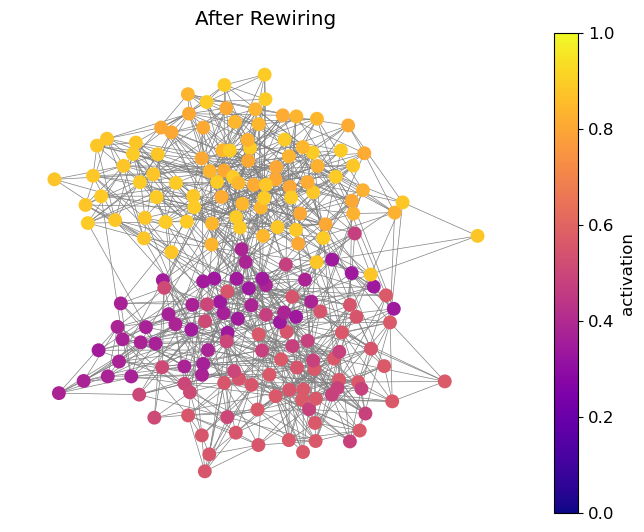

In [35]:
G = generate_network(network,V,d,n_modules=3,p=0.2,seed=rng, show=False)
# show_network(G, 'Initial network', cm.plasma)
# -----------------------------
# Main loop
# -----------------------------
avalanches = []
activity_all = []
avalanche_records = []   # <---- NEW: to store detailed avalanche time series
activation_records = []  # per-update activation snapshots
history = defaultdict(list)

cum_steps = 0
branching_acc_num = 0.0  # sum active_{t+1}
branching_acc_den = 0.0  # sum active_t

edge_use_aval = Counter()   # avalanche-level：每条边被“至少使用过一次”的雪崩数
edge_use_evt  = Counter()   # event-level：每条边成功传播事件次数
n_aval_total = 0

measures0 = compute_network_measures(G)
measures0.update({
    "n_aval": 0,
    "cum_steps": 0,
    "mean_size": np.nan,
    "mean_duration": np.nan,
    "median_size": np.nan,
    "median_duration": np.nan,
    "sigma_hat": np.nan,
})

# baseline (so plots can start from 0)
# cnt = []

for i in range(1, max_avalanches+1):
    update_activation(G,ep,noise_level)
    if i%rewire_every == 0:
        do_rewiring(G, mode)
    # cnt.append(do_rewiring(G, mode))
    # log node activations after slow update/rewiring
    for n in G.nodes():
        activation_records.append({
            "update": i,
            "node": n,
            "activation": G.nodes[n]["activation"]
        })
    # fast
    size, dur, ser, used_edges, used_edges_events = one_avalanche(G, p_base=p_base, rng=rng, track_edges=True)

    n_aval_total += 1
    edge_use_aval.update(used_edges)        # set -> Counter 自动 +1
    edge_use_evt.update(used_edges_events)  # dict edge->count -> Counter 自动累加

    # size, dur, ser = one_avalanche(G, p_base=p_base)
    avalanches.append((size, dur))
    activity_all.extend(ser)
    cum_steps += len(ser)

    # === NEW: record detailed time series of this avalanche ===
    for t, s_t in enumerate(ser):
        avalanche_records.append({
            "avalanche_id": i,
            "t": t,
            "activity": s_t,
            "duration": dur
        })
    
    # periodic logging
    if i % record_every == 1:
        measures = compute_network_measures(G)
        energy = compute_energy(G)
        sizes = np.array([s for s, d in avalanches])
        durs  = np.array([d for s, d in avalanches])
        # sigma_hat = branching_acc_num / (branching_acc_den + 1e-12)
    if i % record_every == 1:
        measures = compute_network_measures(G)
        energy = compute_energy(G)

        measures.update({
            "n_aval": i,
            "cum_steps": cum_steps,
            "mean_size": float(np.mean(sizes)),
            "mean_duration": float(np.mean(durs)),
            "median_size": float(np.median(sizes)),
            "median_duration": float(np.median(durs)),
            "energy": float(energy),

        })
        for k, v in measures.items():
            history[k].append(v)
            


show_network(G, 'After Rewiring', cm.plasma)
# === Save all results ===
pd.DataFrame(history).to_csv(f"network_measures_{mode}_{V}.csv", index=False)
pd.DataFrame({"activity": activity_all}).to_csv(f"global_activity_{mode}_{V}.csv", index=False)
pd.DataFrame(avalanches, columns=["size", "duration"]).to_csv(f"avalanches_{mode}_{V}.csv", index=False)
pd.DataFrame(avalanche_records).to_csv(f"avalanches_detailed_{mode}_{V}.csv", index=False)  # <---- NEW
pd.DataFrame(activation_records).to_csv(f"activation_series_{mode}_{V}.csv", index=False)


## Dynamical Behaviour Plots


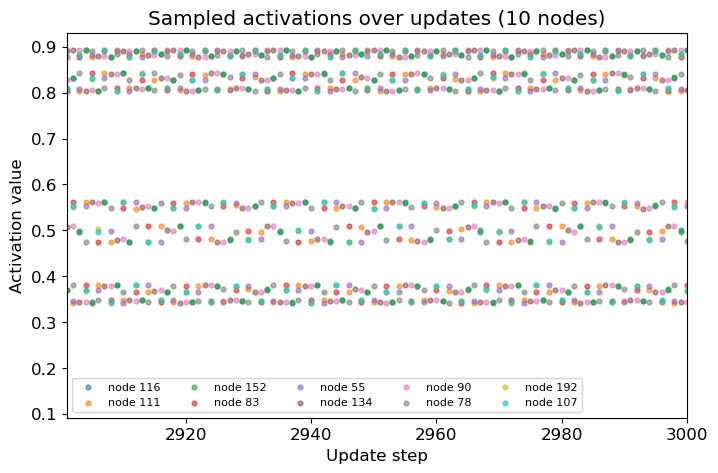

In [36]:
# Activation trajectories for sampled nodes
df_activation = pd.DataFrame(activation_records) if 'activation_records' in locals() and len(activation_records) > 0 else pd.read_csv(f"activation_series_{mode}_{V}.csv")
unique_nodes = df_activation['node'].unique()
sample_size = min(10, len(unique_nodes))
sample_nodes = rng.choice(unique_nodes, size=sample_size, replace=False) if sample_size > 0 else []

plt.figure(figsize=(8, 5))
for node in sample_nodes:
    node_data = df_activation[df_activation['node'] == node]
    plt.scatter(node_data['update'], node_data['activation'], s=12, alpha=0.6, label=f'node {node}')
plt.xlabel('Update step')
plt.ylabel('Activation value')
plt.xlim((2901,3000))
plt.title(f'Sampled activations over updates ({sample_size} nodes)')
plt.legend(markerscale=1, fontsize=8, ncol=5)
plt.show()


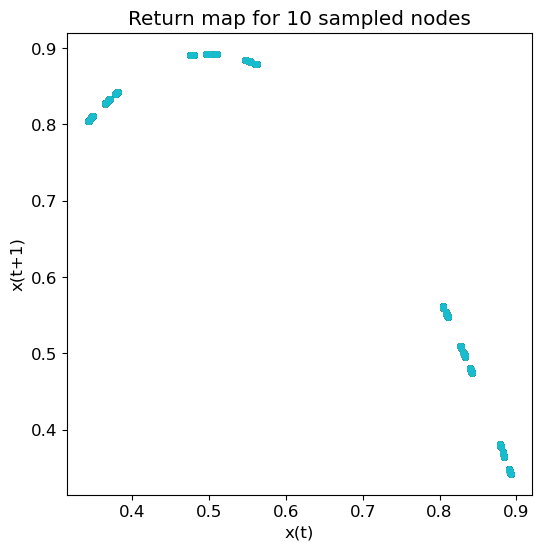

In [37]:
# Activation return map (x_t vs x_{t+1})
df_activation = pd.DataFrame(activation_records) if 'activation_records' in locals() and len(activation_records) > 0 else pd.read_csv(f"activation_series_{mode}_{V}.csv")
unique_nodes = df_activation['node'].unique()
sample_size = min(10, len(unique_nodes))
sample_nodes = rng.choice(unique_nodes, size=sample_size, replace=False) if sample_size > 0 else []

plt.figure(figsize=(6, 6))
for node in sample_nodes:
    node_data = df_activation[df_activation['node'] == node].sort_values('update')
    vals = node_data['activation'].values
    if len(vals) < 2:
        continue
    plt.scatter(vals[1000:-1], vals[1001:], s=12, alpha=0.7, label=f'node {node}')
plt.xlabel('x(t)')
plt.ylabel('x(t+1)')
plt.title(f'Return map for {sample_size} sampled nodes')
# plt.legend(markerscale=1, fontsize=8, ncol=3)
plt.show()


## Network Measurements


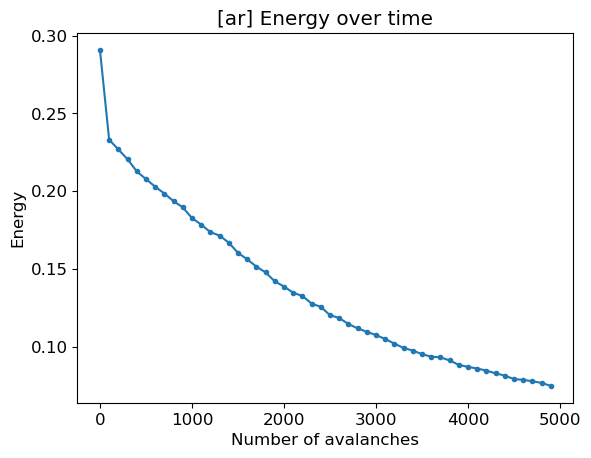

In [38]:
df = pd.read_csv(f"network_measures_{mode}_{V}.csv")

energy = df["energy"].values
steps = df["n_aval"].values

plt.figure()
plt.plot(steps, energy, '.-')
plt.xlabel("Number of avalanches")
plt.ylabel("Energy")
plt.title(f"[{mode}] Energy over time")
plt.show()


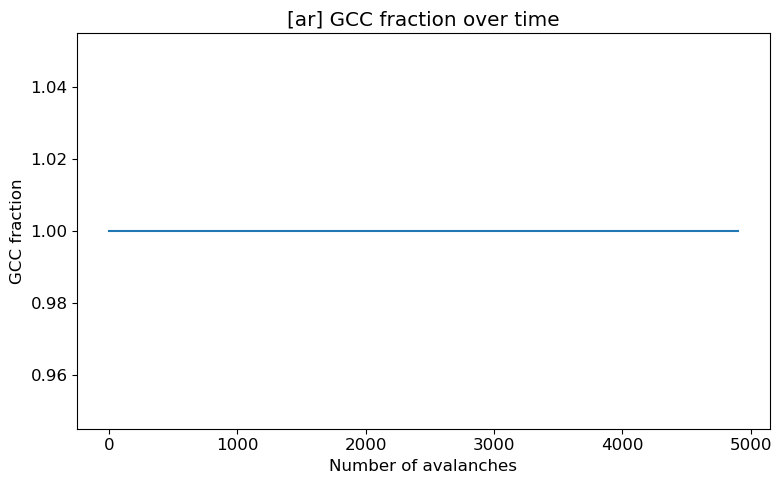

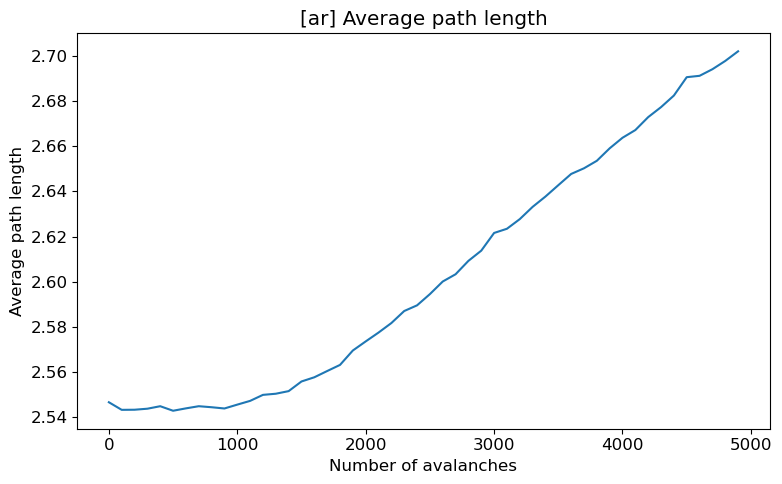

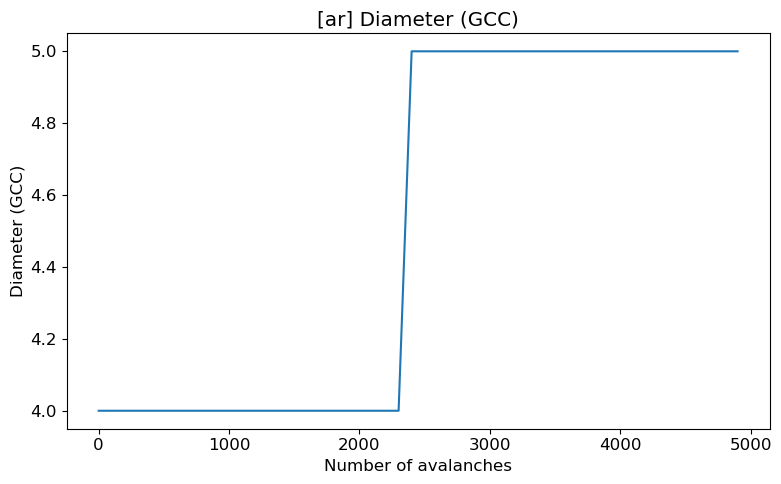

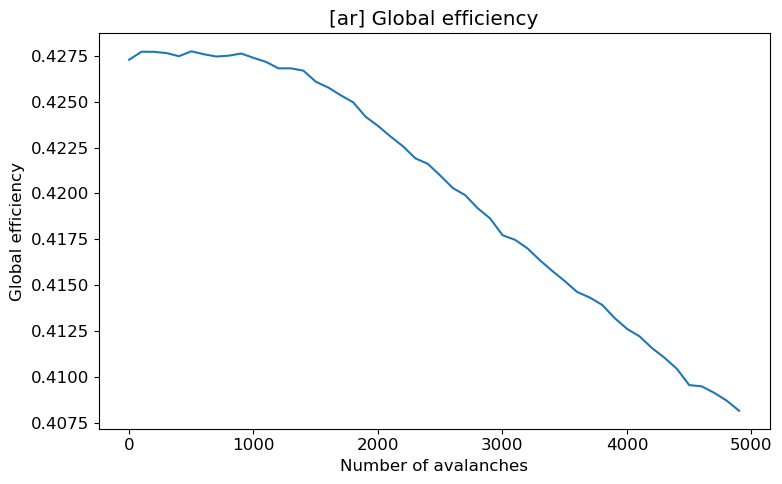

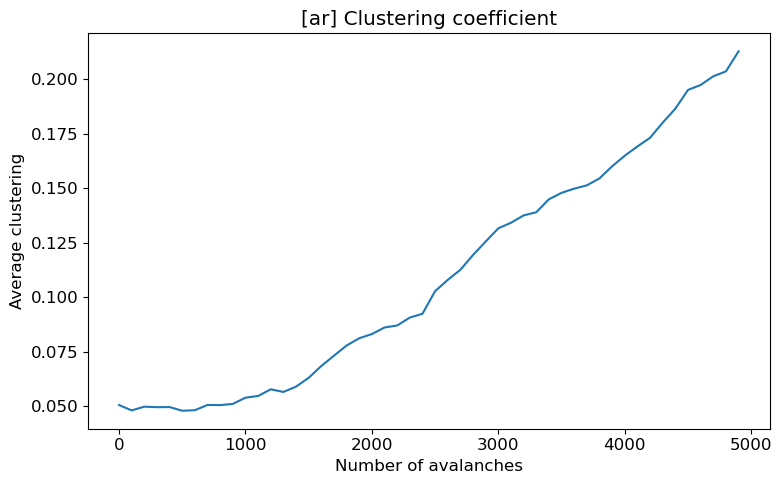

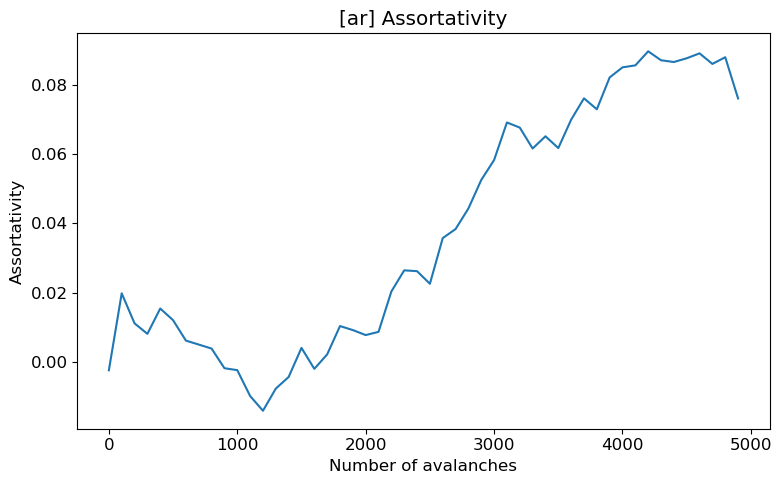

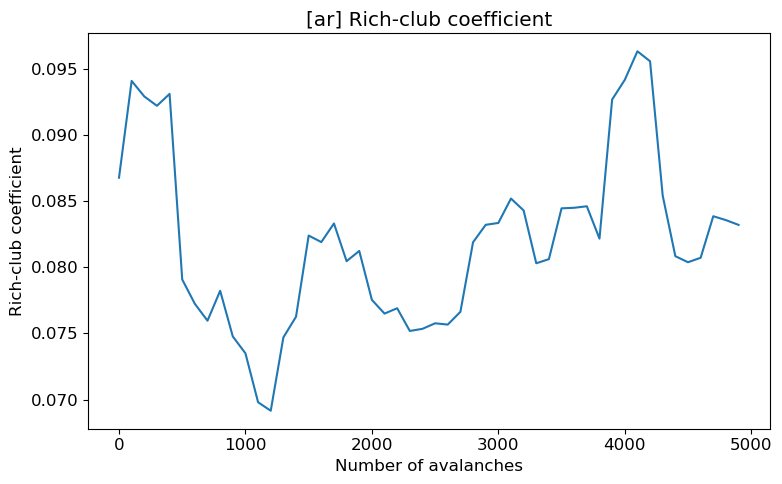

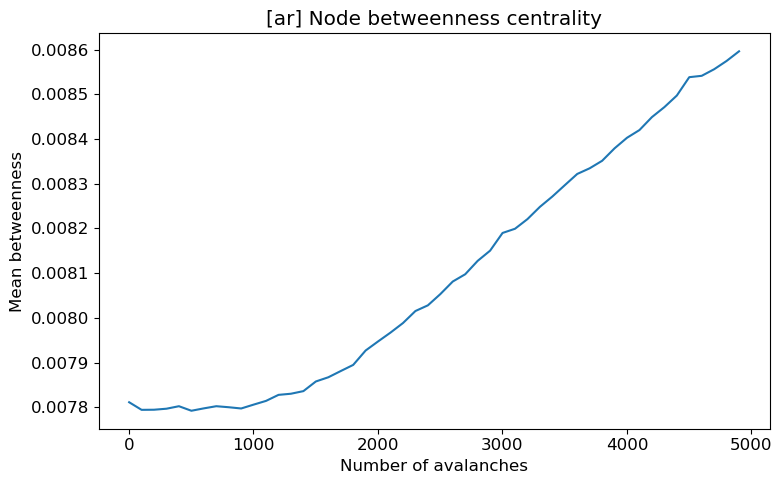

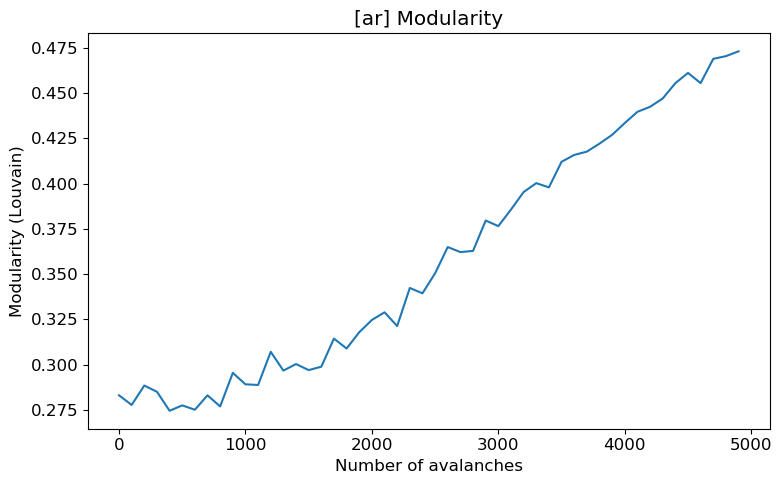

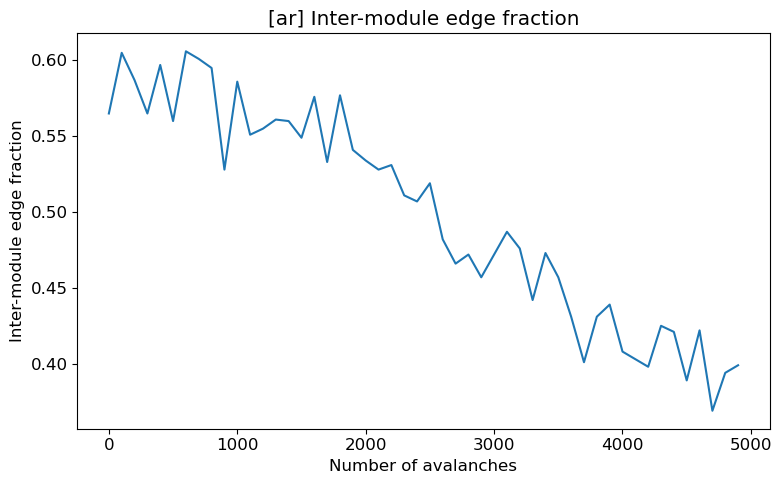

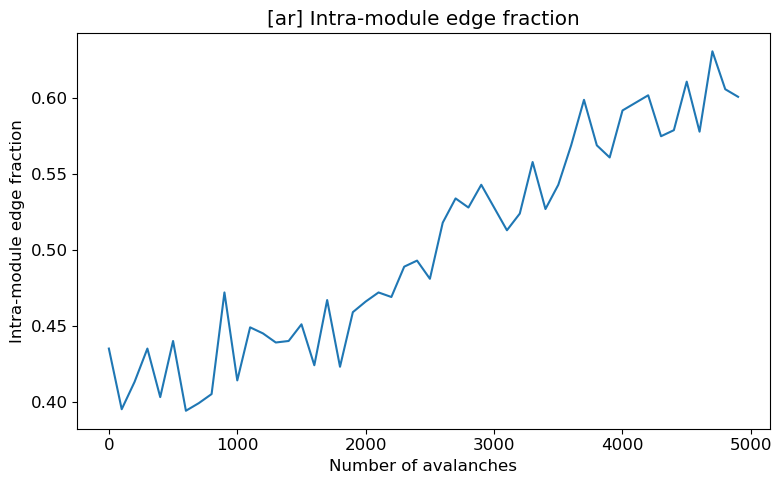

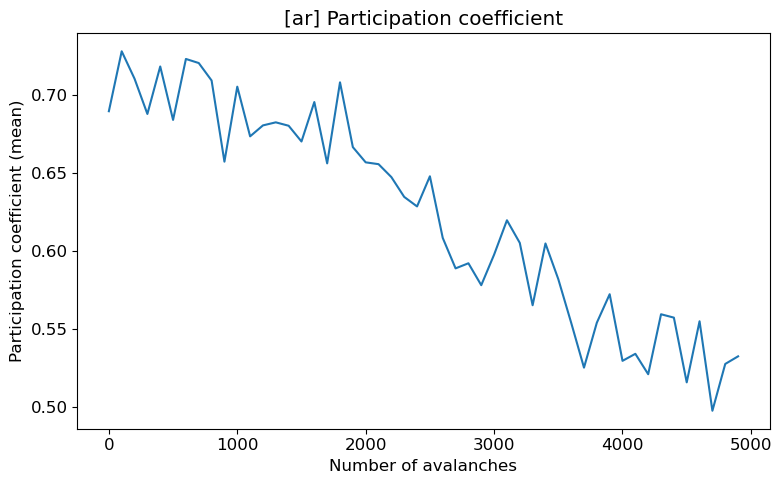

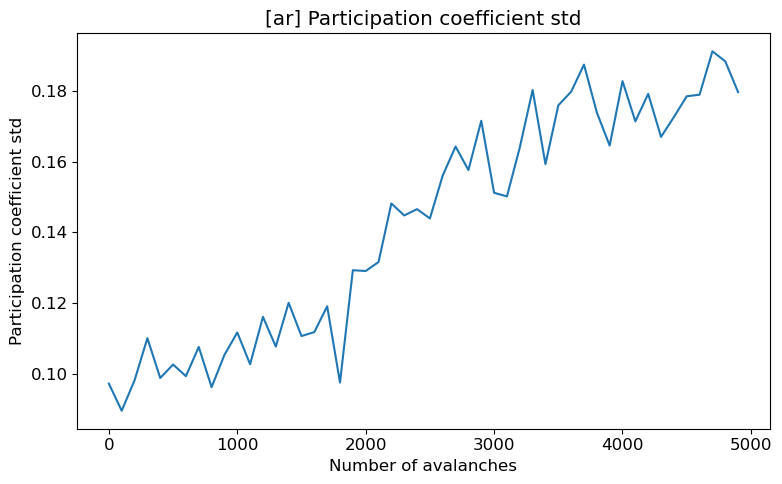

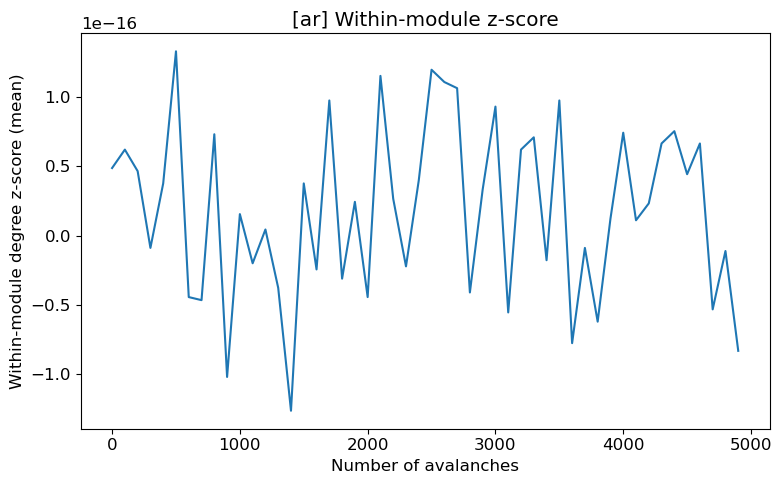

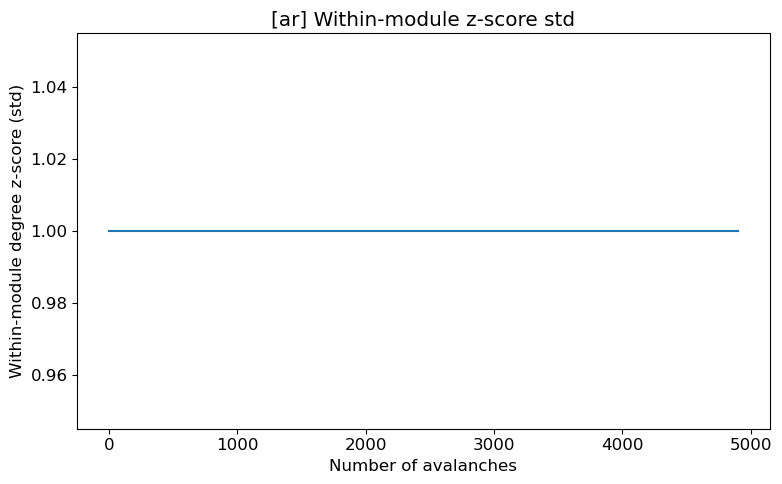

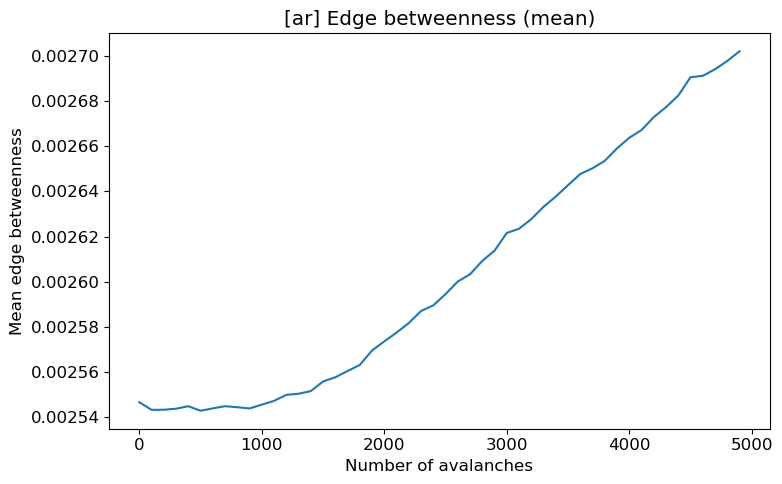

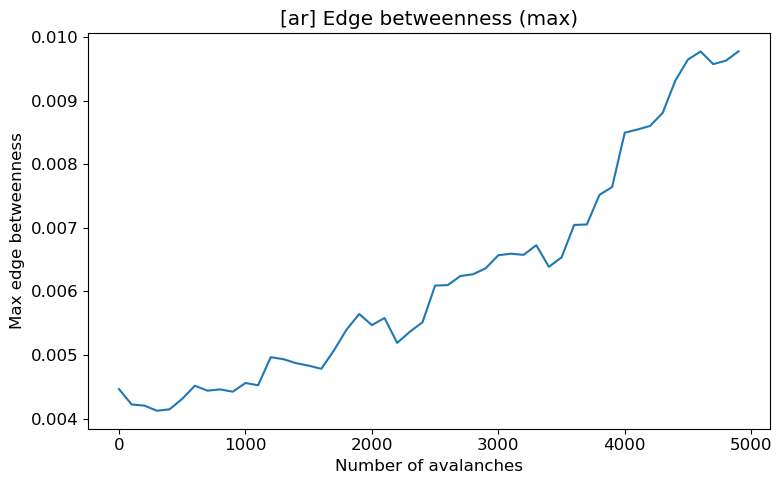

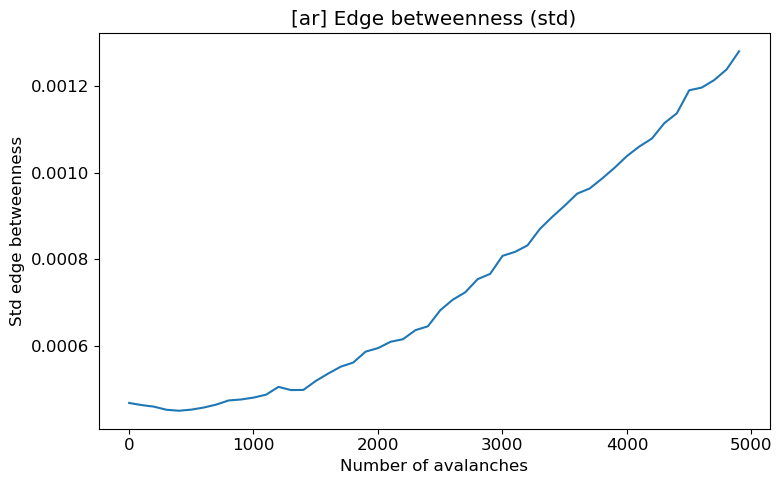

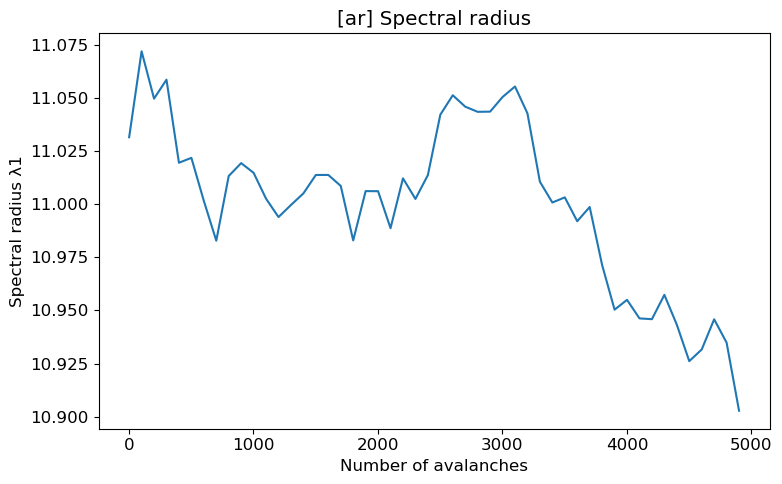

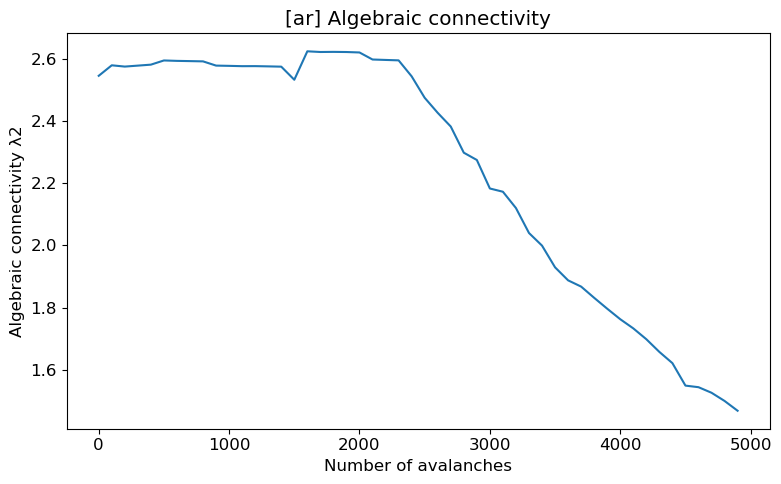

In [39]:
use_steps = False   # True: fast timescale (`cum_steps`); False: slow timescale (`n_aval`)
df_net = pd.read_csv(f"network_measures_{mode}_{V}.csv")
df_aval = pd.read_csv(f"avalanches_{mode}_{V}.csv")
df_act = pd.read_csv(f"global_activity_{mode}_{V}.csv")
try:
    df_lrtc = pd.read_csv(f"lrtc_summary_{mode}_{V}.csv")
except FileNotFoundError:
    df_lrtc = pd.DataFrame()


def get_x():
    if use_steps:
        if "cum_steps" in df_net.columns:
            return df_net["cum_steps"].values, "Steps"
        return np.arange(len(df_net)), "Steps (proxy)"

    if "n_aval" in df_net.columns:
        return df_net["n_aval"].values, "Number of avalanches"
    return np.arange(len(df_net)), "Number of avalanches (proxy)"


x_axis, xlabel = get_x()


def lineplot(y, ylabel, title, fname):
    plt.figure(figsize=(8, 5))
    plt.plot(x_axis, y, lw=1.5)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.show()


def maybe_plot(col, ylabel, title, fname):
    if col in df_net.columns:
        lineplot(df_net[col], ylabel, title, fname)
    else:
        print(f"Column {col} not found; skipping.")


# Basic graph metrics
maybe_plot("gcc_frac", "GCC fraction", f"[{mode}] GCC fraction over time", f"fig_{mode}_gcc_frac.png")
maybe_plot("avg_path_length", "Average path length", f"[{mode}] Average path length", f"fig_{mode}_apl.png")
maybe_plot("diameter", "Diameter (GCC)", f"[{mode}] Diameter (GCC)", f"fig_{mode}_diam.png")
maybe_plot("efficiency", "Global efficiency", f"[{mode}] Global efficiency", f"fig_{mode}_eff.png")
maybe_plot("clustering", "Average clustering", f"[{mode}] Clustering coefficient", f"fig_{mode}_clust.png")
maybe_plot("assortativity", "Assortativity", f"[{mode}] Assortativity", f"fig_{mode}_assort.png")
maybe_plot("rich_club_coeff", "Rich-club coefficient", f"[{mode}] Rich-club coefficient", f"fig_{mode}_rc.png")
maybe_plot("betweenness", "Mean betweenness", f"[{mode}] Node betweenness centrality", f"fig_{mode}_betweenness.png")
maybe_plot("modularity", "Modularity (Louvain)", f"[{mode}] Modularity", f"fig_{mode}_modularity.png")

# Community-structure metrics
maybe_plot("inter_edge_frac", "Inter-module edge fraction", f"[{mode}] Inter-module edge fraction", f"fig_{mode}_inter_edges.png")
maybe_plot("intra_edge_frac", "Intra-module edge fraction", f"[{mode}] Intra-module edge fraction", f"fig_{mode}_intra_edges.png")
maybe_plot("participation_mean", "Participation coefficient (mean)", f"[{mode}] Participation coefficient", f"fig_{mode}_participation_mean.png")
maybe_plot("participation_std", "Participation coefficient std", f"[{mode}] Participation coefficient std", f"fig_{mode}_participation_std.png")
maybe_plot("wmdeg_z_mean", "Within-module degree z-score (mean)", f"[{mode}] Within-module z-score", f"fig_{mode}_wmz_mean.png")
maybe_plot("wmdeg_z_std", "Within-module degree z-score (std)", f"[{mode}] Within-module z-score std", f"fig_{mode}_wmz_std.png")

# Edge-betweenness metrics
maybe_plot("edge_bw_mean", "Mean edge betweenness", f"[{mode}] Edge betweenness (mean)", f"fig_{mode}_edgebw_mean.png")
maybe_plot("edge_bw_max", "Max edge betweenness", f"[{mode}] Edge betweenness (max)", f"fig_{mode}_edgebw_max.png")
maybe_plot("edge_bw_std", "Std edge betweenness", f"[{mode}] Edge betweenness (std)", f"fig_{mode}_edgebw_std.png")

# Spectral metrics
maybe_plot("spectral_radius", "Spectral radius λ1", f"[{mode}] Spectral radius", f"fig_{mode}_spec_radius.png")
maybe_plot("algebraic_connectivity", "Algebraic connectivity λ2", f"[{mode}] Algebraic connectivity", f"fig_{mode}_algconn.png")


## Avalanche Exponents


In [40]:
# -----------------------------
# LRTC summary (DFA and PSD slope) on the full activity series
# -----------------------------
dfa_val = dfa_alpha(activity_all)
series_length = int(len(activity_all))
aval_count = int(len(avalanches))

slope, info = psd_loglog_slope_robust(activity_all, fs=1.0, band=(1 / 2000, 0.05), use_diff=False)

df_lrtc_summary = pd.DataFrame([{
    "dfa_alpha": dfa_val,
    "psd_slope": slope,
    "psd_r2": info.get("r2", np.nan),
    "psd_fit_method": info.get("robust", "unknown"),
    "series_length": series_length,
    "aval_count": aval_count,
    "mode": mode,
    "p_base": p_base,
}])
df_lrtc_summary.to_csv(f"lrtc_summary_{mode}_{V}.csv", index=False)

df_lrtc_summary


,dfa_alpha,psd_slope,psd_r2,psd_fit_method,series_length,aval_count,mode,p_base
0,0.853247,-0.715432,0.772001,huber,24914,5000,ar,0.1


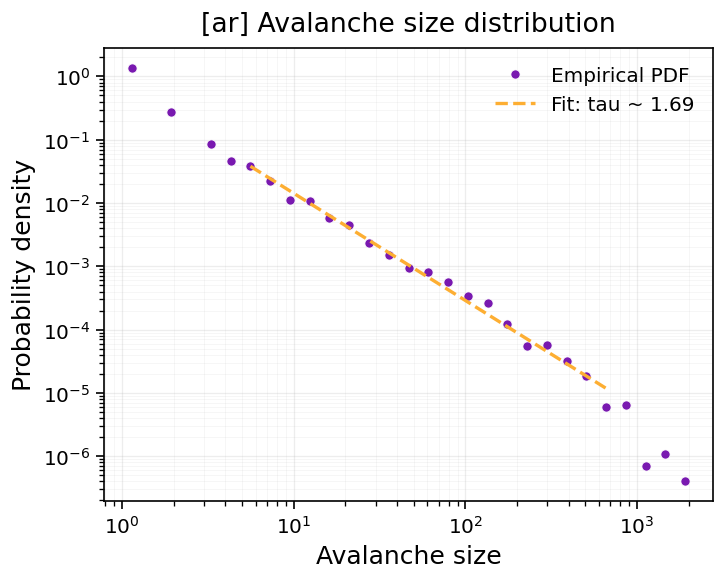

[ar] Avalanche size distribution: spans ~3.34 decades (min=1, max=2.18e+03)


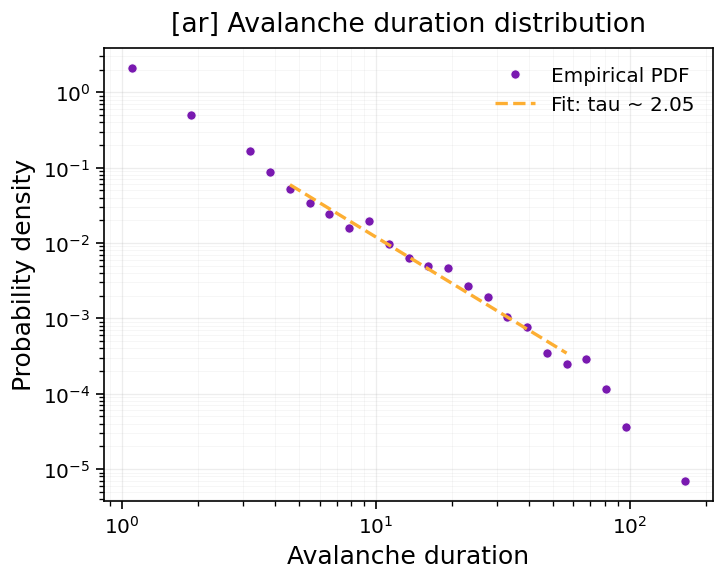

[ar] Avalanche duration distribution: spans ~2.26 decades (min=1, max=181)
Span (decades): size≈3.34, duration≈2.26


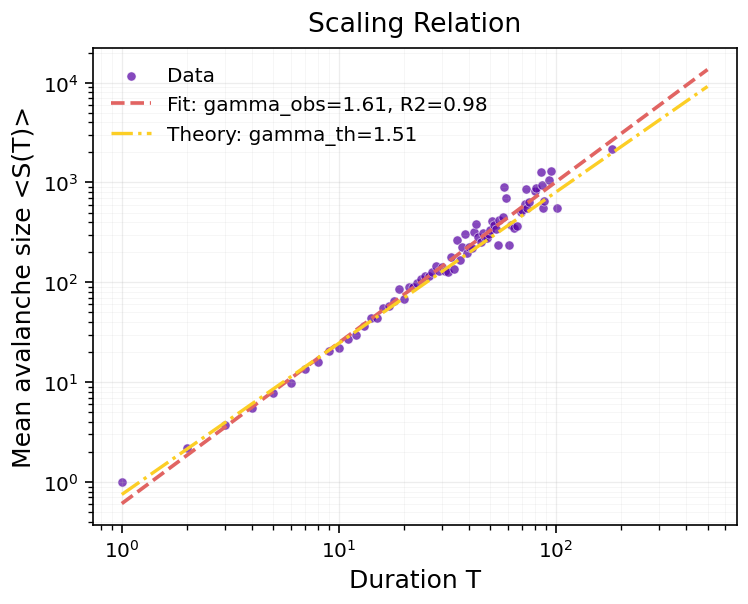


--- Scaling Consistency ---
γ_obs (fit)       = 1.611 ± 0.030
γ_theory          = 1.514
Δγ (obs - theory) = 0.096
Relative Δγ       = 6.37%
R² (fit quality)  = 0.975
---------------------------


In [41]:
df_aval = pd.read_csv(f"avalanches_{mode}_{V}.csv") 
df_aval = df_aval.iloc[200:-1]
tau_s, span_size = loglog_hist(df_aval["size"].values, nbins=30, xlabel="Avalanche size",
            title=f"[{mode}] Avalanche size distribution", fname=f"fig_{mode}_aval_size.png")
tau_d, span_dur = loglog_hist(df_aval["duration"].values, nbins=30, xlabel="Avalanche duration",
            title=f"[{mode}] Avalanche duration distribution", fname=f"fig_{mode}_aval_dur.png")
print(f"Span (decades): size≈{span_size:.2f}, duration≈{span_dur:.2f}")

res = compare_scaling(df_aval, tau_s, tau_d,
                      duration_range=(1, 500),
                      savefig="scaling_relation.png")


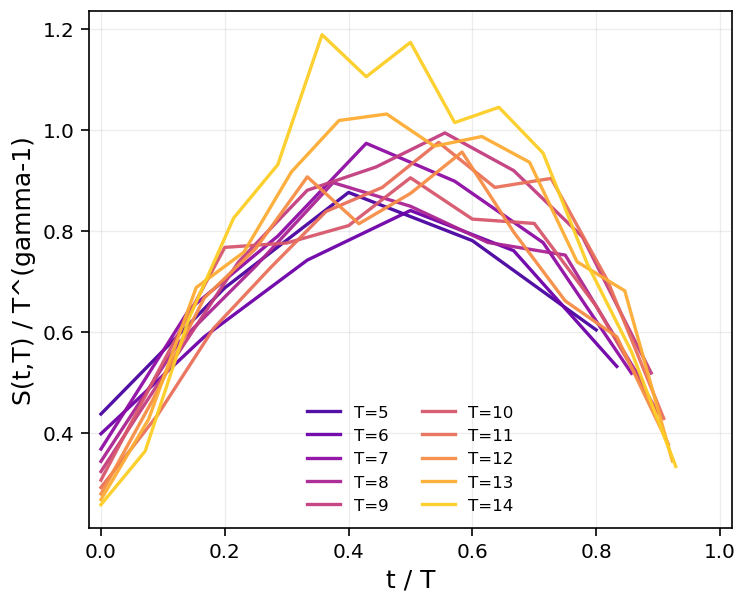

In [42]:
# Load the detailed avalanche time series.
df = pd.read_csv(f"avalanches_detailed_{mode}_{V}.csv")

# Estimate gamma from the scaling relation S ~ T^gamma.
gamma = (tau_d + 1) / (tau_s + 1)

# Collapse-plot settings.
T_min, T_max = 5, 14
n_curves = 10
show_legend = True
savefig = None  # e.g. f"collapse_{mode}_{V}.png"

durations_all = np.array(sorted(df["duration"].unique()))
durations_sel = durations_all[(durations_all >= T_min) & (durations_all <= T_max)]
if len(durations_sel) == 0:
    raise ValueError("No durations fall in [T_min, T_max].")

idx = np.linspace(0, len(durations_sel) - 1, min(n_curves, len(durations_sel)), dtype=int)
durations_to_plot = durations_sel[idx]
colors = plt.cm.plasma(np.linspace(0.12, 0.90, len(durations_to_plot)))

fig, ax = plt.subplots(figsize=(6.4, 5.2), dpi=120)
for c, T in zip(colors, durations_to_plot):
    subset = df[df["duration"] == T]
    mean_shape = subset.groupby("t")["activity"].mean()
    x_scaled = mean_shape.index.values / T
    y_scaled = mean_shape.values / (T ** (gamma - 1))
    ax.plot(x_scaled, y_scaled, color=c, linewidth=2.0, alpha=0.95, label=f"T={int(T)}")

ax.set_xlabel("t / T", fontsize=15)
ax.set_ylabel("S(t,T) / T^(gamma-1)", fontsize=15)
ax.set_xlim(-0.02, 1.02)
ax.tick_params(axis="both", which="major", labelsize=12, length=5, width=1.0)
ax.tick_params(axis="both", which="minor", length=3, width=0.8)
ax.grid(which="major", alpha=0.22, linewidth=0.8)
ax.grid(which="minor", alpha=0.10, linewidth=0.5)
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
if show_legend:
    ax.legend(frameon=False, fontsize=10, ncol=2, loc="best")
fig.tight_layout()
if savefig:
    fig.savefig(savefig, dpi=300, bbox_inches="tight")
plt.show()


## Cross-Mode Comparison


In [ ]:
plt.figure(figsize=(6, 5))

mode_order = ['no', 'random-dp', 'random', 'ar']
plasma_colors = plt.cm.plasma(np.linspace(0.12, 0.88, len(mode_order)))
mode_colors = {m: plasma_colors[i] for i, m in enumerate(mode_order)}
mode_labels = {
    'no': 'No rewiring',
    'random-dp': 'DP-random',
    'random': 'Random rewiring',
    'ar': 'Adaptive rewiring',
}

for mode in mode_order:
    df = pd.read_csv(f"network_measures_{mode}_{V}.csv")
    energy = df["energy"].values
    steps = df["n_aval"].values
    plt.plot(steps, energy, c=mode_colors[mode], linestyle='-', linewidth=2, label=mode_labels[mode])

plt.xlabel("Number of avalanches")
plt.ylabel("Energy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
for mode in mode_order:
    df = pd.read_csv(f"network_measures_{mode}_{V}.csv")
    energy = df["energy"].values
    d_energy = np.diff(energy)
    plt.scatter(energy[:-1], d_energy, alpha=0.6, s=20, c=mode_colors[mode], label=mode_labels[mode])

plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Energy")
plt.ylabel("ΔEnergy")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
tp = 'size'  # 'duration' or 'size'
V = 200
plt.figure(figsize=(6, 5))

mode_order = ['no', 'random-dp', 'random', 'ar']
plasma_colors = plt.cm.plasma(np.linspace(0.12, 0.88, len(mode_order)))
mode_colors = {m: plasma_colors[i] for i, m in enumerate(mode_order)}
mode_labels = {
    'no': 'No rewiring',
    'random-dp': 'DP-random',
    'random': 'Random rewiring',
    'ar': 'Adaptive rewiring',
}

for mode in mode_order:
    centers, hist = plot_all_mode_pdf(mode, tp, V, 20)
    plt.loglog(centers, hist, c=mode_colors[mode], linestyle='-', linewidth=2, label=mode_labels[mode])

# Reference power-law slope.
if tp == 'size':
    k = -1.5
    x0 = 4
elif tp == 'duration':
    k = -2.0
    x0 = 3

x_ref = np.logspace(0, x0, 100)
y0 = 1
y_ref = y0 * (x_ref / x_ref[0]) ** k
plt.loglog(x_ref, y_ref, '--', color='k', linewidth=1, label=f'slope = {k}')

plt.xlabel(tp.capitalize())
plt.ylabel('PDF')
plt.title(f'Avalanche {tp} PDF')
plt.legend()
plt.tight_layout()
plt.show()
